# Chapter 3 · The causal ladder — ad spend → streams
### European label · daily Spotify streams + paid-social spend

**Where we are.** Earlier chapters simulated releases and daily streams. Now the label
adds **paid-social spend** (TikTok, Instagram) and wants **causal** answers, not
correlations: *how many streams did the ads actually cause?*

**Data sources (assumed first-party).**
- **Streams** — daily, per country, from **Spotify for Artists / S4A API** (the label's own).
- **Spend** — daily, per country, per channel, from the **TikTok / Meta Ads** APIs.

> **Why this is hard.** Spend is **not random**. The label funds the releases and the
> moments it already expects to do well, and it tends to push paid media into the
> *post-launch decay phase* to prop up a fading song. So raw correlation between spend
> and streams is **confounded** — and as we'll see, it can even come out *negative*.
> Every rung of the ladder builds a more credible **counterfactual** (what would
> streams have been *without* the ads?).

## The five causal questions
1. **Incrementality** — extra streams *caused* by paid social vs. the organic baseline → **iROAS** (streams/€), cost-per-incremental-stream.
2. **Channel effectiveness (MMM)** — each channel's contribution with **adstock** (carryover) + **saturation** (diminishing returns); marginal ROAS; budget reallocation.
3. **Per-campaign geo-lift** — effect of switching spend on in some countries.
4. **Heterogeneity** — by artist tier, country, channel, release phase.
5. **Dynamics** — adstock length; does advertising extend the release tail?

## The estimand
The **ATT**: the **% lift in streams in treated geos during the campaign**, and the
**iROAS**. Because this is synthetic, we **bake in the true effect** and score every
estimator against it.

## The ladder (basic → ideal) and what each one buys you
| # | Method | Identifying assumption | Fixes | Tool |
|---|---|---|---|---|
| 0 | Naive OLS / pre-post | none (correlation) | — | statsmodels |
| 1 | TWFE on spend | selection on FE only | unit/time levels | pyfixest |
| 2 | DiD 2×2 | parallel trends | common shocks | pyfixest |
| 3 | Staggered DiD (Sun–Abraham) | parallel trends, no-anticipation | **staggered-timing bias** | pyfixest |
| 4 | Synthetic Control | convex pre-fit of donors | one treated unit, weights | pysyncon |
| 5 | Synthetic DiD | unit **and** time weights | robustness, bias | from scratch |
| 6 | Augmented SCM (**GeoLift** core) | ridge-relaxed fit | poor pre-fit / extrapolation | pysyncon |
| 7 | Bayesian SC | as SC + priors | **uncertainty** | CausalPy |
| 8 | **Bayesian MMM** | adstock+Hill, calibrated | always-on budget, all channels | pymc-marketing |

We use the real production libraries the way you would on the job; `synthdid` has no
maintained Python port, so it's implemented from scratch (and we cite the R original).

## 1 · Setup

The data-generating process (`make_causal_panel`) and its primitives (`adstock`, `hill`)
now live in the shared `mml` module — one source of truth across the lab — and
`ground_truth` exposes the planted lift / iROAS so every estimator can be scored.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
from mml import make_causal_panel, ground_truth

import logging; logging.disable(logging.WARNING)
import matplotlib.dates as mdates
plt.rcParams.update({"figure.figsize": (11, 4.5), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
BLUE, RED, GREEN, GREY = "#3b6fb0", "#d1495b", "#66a182", "#9e9e9e"

## 2 · The data-generating process (with known ground truth)

A **country × day** panel of streams for one **flagship single** launched across **12
European markets**, observed for 17 weeks.

- **Organic** streams = market-size × release spike × exponential decay × weekly
  seasonality × a **common** national shock (so geos co-move — essential for DiD/SC).
- **Paid boost** rolls out **staggered**: 8 treated countries in 3 cohorts (start days
  28 / 42 / 56), and **4 held-out controls** (FR, NL, PT, DK) — a classic geo holdout.
- **Incremental** streams = `Hill(adstock(spend))` per channel, with **known**
  carryover (θ) and saturation — this is the causal effect we'll try to recover.
- **Confounding**: spend ramps *during the decay phase*, so naive spend↔streams
  correlation is negative.

The DGP is calibrated so the all-treated lift is **≈ 16%** and iROAS **≈ 16.7 streams/€**,
with a clearly **negative** national spend↔streams correlation (≈ −0.68) — the confounding
money-shot.

In [ ]:
df, meta = make_causal_panel(seed=0)
df["ly"] = np.log(df.streams.clip(lower=1))               # log streams for proportional (DiD) effects
geo = df[["country", "size"]].drop_duplicates().reset_index(drop=True)
print("panel:", df.shape, "| countries:", df.country.nunique(), "| days:", df.t.nunique())
df.head()

panel: (1428, 14) | countries: 12 | days: 119


,country,size,date,t,treated,start_day,post,tiktok,instagram,organic,incremental,streams,spend,ly
0,DE,1.0,2026-03-06,0,1,28,0,0.0,0.0,60464.265924,0.0,60379.0,0.0,11.008397
1,DE,1.0,2026-03-07,1,1,28,0,0.0,0.0,62249.823108,0.0,62198.0,0.0,11.038078
2,DE,1.0,2026-03-08,2,1,28,0,0.0,0.0,65208.748535,0.0,65119.0,0.0,11.083972
3,DE,1.0,2026-03-09,3,1,28,0,0.0,0.0,51965.209004,0.0,51776.0,0.0,10.854682
4,DE,1.0,2026-03-10,4,1,28,0,0.0,0.0,50404.857044,0.0,50574.0,0.0,10.831193


### Ground-truth effects (what every estimator is trying to recover)

In [ ]:
gt = ground_truth(df, meta)
tp = df[(df.treated == 1) & (df.post == 1)]                      # treated, post
de = df[(df.country == "DE") & (df.t >= meta["start_day"]["DE"])]  # DE, post
g28 = df[(df.country.isin(meta["cohorts"][28])) & (df.t >= 28)]    # early cohort, post
def lift(d): return d.incremental.sum() / d.organic.sum()
SCOPE = {  # scope -> (true_lift, organic_streams, spend)
 "national":    (df.incremental.sum() / df.organic.sum(), df.organic.sum(), df.spend.sum()),
 "all_treated": (lift(tp),  tp.organic.sum(),  tp.spend.sum()),
 "de":          (lift(de),  de.organic.sum(),  de.spend.sum()),
 "cohort28":    (lift(g28), g28.organic.sum(), g28.spend.sum()),
}
true_iroas = tp.incremental.sum() / tp.spend.sum()
print(f"TRUE % lift  -> all-treated {lift(tp):.1%} | DE {lift(de):.1%} | national {SCOPE['national'][0]:.1%}")
print(f"TRUE iROAS   -> {true_iroas:.1f} streams per EUR  (cost per incremental stream EUR {1/true_iroas:.3f})")
print(f"Total boost spend: EUR {df.spend.sum():,.0f} | total incremental streams: {tp.incremental.sum():,.0f}")

RESULTS = {}
def record(name, lift_est, scope):
    truth, org, sp = SCOPE[scope]
    RESULTS[name] = dict(lift=lift_est, scope=scope, truth=truth,
                         iroas=lift_est * org / sp, rel_bias=lift_est / truth - 1)
    print(f"  {name:30s} lift={lift_est:+.1%}  (truth {truth:.1%}, scope={scope}, iROAS={lift_est * org / sp:+.1f})")

TRUE % lift  -> all-treated 15.7% | DE 20.2% | national 4.4%
TRUE iROAS   -> 16.7 streams per EUR  (cost per incremental stream EUR 0.060)
Total boost spend: EUR 40,205 | total incremental streams: 673,187


## 3 · See the confounding first

Two pictures that explain why we can't just regress streams on spend.

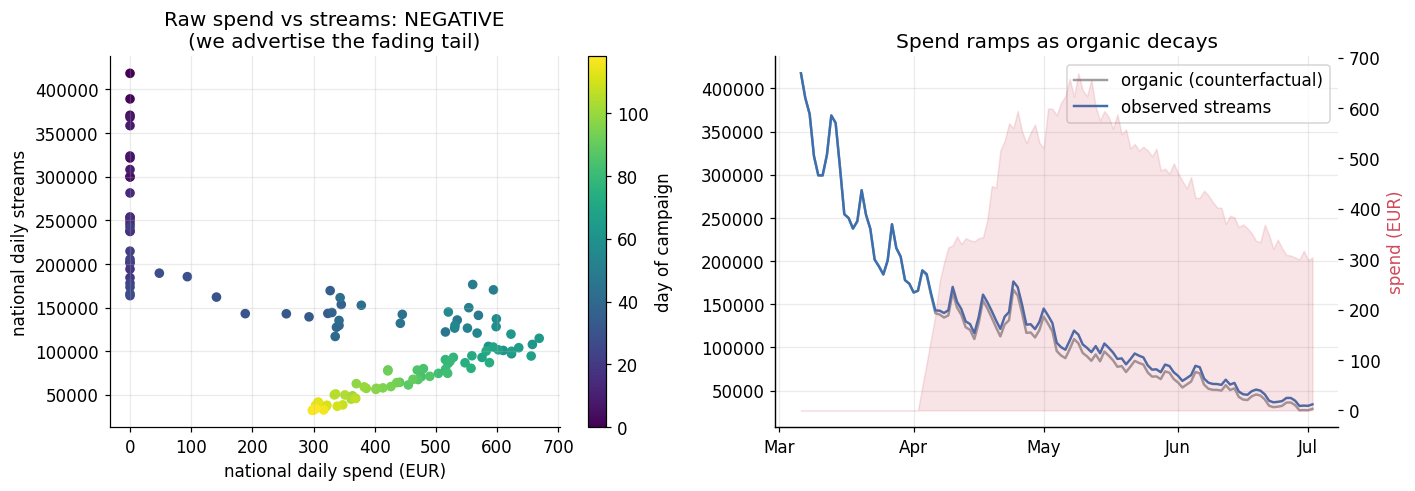

corr(spend, streams) = -0.68  <-- naive analyst concludes ads HURT


In [ ]:
nat = df.groupby("date").agg(streams=("streams", "sum"), spend=("spend", "sum"),
        organic=("organic", "sum"), incremental=("incremental", "sum")).reset_index()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
sc = a1.scatter(nat.spend, nat.streams, c=np.arange(len(nat)), cmap="viridis", s=28)
a1.set_xlabel("national daily spend (EUR)"); a1.set_ylabel("national daily streams")
a1.set_title("Raw spend vs streams: NEGATIVE\n(we advertise the fading tail)")
plt.colorbar(sc, ax=a1, label="day of campaign")
a2.plot(nat.date, nat.organic, color=GREY, lw=1.6, label="organic (counterfactual)")
a2.plot(nat.date, nat.organic + nat.incremental, color=BLUE, lw=1.6, label="observed streams")
a2b = a2.twinx(); a2b.fill_between(nat.date, nat.spend, color=RED, alpha=0.15); a2b.set_ylabel("spend (EUR)", color=RED)
a2.set_title("Spend ramps as organic decays"); a2.legend(loc="upper right"); a2b.grid(False)
a2.xaxis.set_major_locator(mdates.MonthLocator()); a2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout(); plt.show()
print(f"corr(spend, streams) = {nat.spend.corr(nat.streams):+.2f}  <-- naive analyst concludes ads HURT")

### The staggered geo design

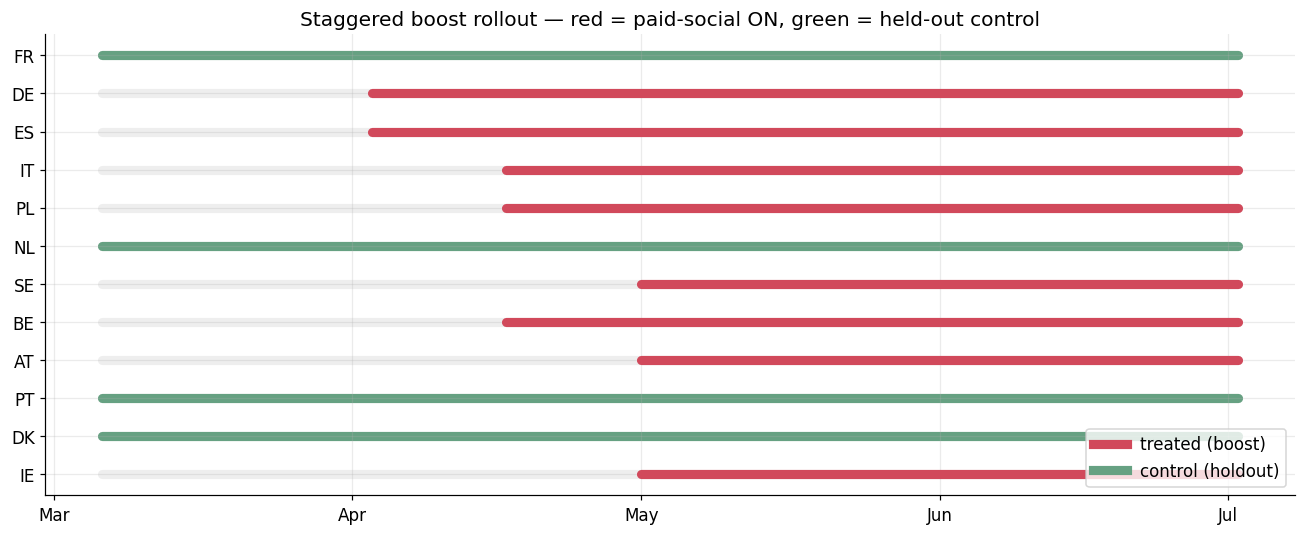

In [ ]:
order = geo.sort_values("size").country.tolist()
ypos = {c: i for i, c in enumerate(order)}
fig, ax = plt.subplots(figsize=(12, 5))
for c in order:
    d = df[df.country == c]; sd = meta["start_day"][c]
    ax.plot(d.date, [ypos[c]] * len(d), color="#eee", lw=6, solid_capstyle="round", zorder=0)
    if sd is not None:
        post = d[d.t >= sd]
        ax.plot(post.date, [ypos[c]] * len(post), color=RED, lw=6, solid_capstyle="round", zorder=2)
    else:
        ax.plot(d.date, [ypos[c]] * len(d), color=GREEN, lw=6, solid_capstyle="round", zorder=1)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_title("Staggered boost rollout — red = paid-social ON, green = held-out control")
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0], [0], color=RED, lw=6, label="treated (boost)"),
                   Line2D([0], [0], color=GREEN, lw=6, label="control (holdout)")], loc="lower right")
plt.tight_layout(); plt.show()

## 4 · Rung 0–1 · Naive correlation & TWFE on spend

The instinctive move: regress streams on spend. **Both fail**, because spend is timed
into the decay phase — on the **national daily aggregate** the spend↔streams correlation
even flips *negative* (§3); two-way fixed effects barely helps.

In [ ]:
import statsmodels.formula.api as smf, pyfixest as pf
ols = smf.ols("streams ~ spend", df).fit()
b_ols = ols.params["spend"]
record("0 Naive OLS (streams~$)", b_ols * tp.spend.sum() / tp.organic.sum(), "all_treated")

twfe = pf.feols("streams ~ spend | country + date", df)
b_twfe = twfe.coef()["spend"]
record("1 TWFE on spend", b_twfe * tp.spend.sum() / tp.organic.sum(), "all_treated")

# also the simplest mistake: pre/post in treated only (no control)
naive_pp = np.expm1(df[(df.treated == 1) & (df.post == 1)].ly.mean() - df[(df.treated == 1) & (df.post == 0)].ly.mean())
record("0b Pre/post, no control", naive_pp, "all_treated")
# The confounding bites hardest on the NATIONAL DAILY AGGREGATE: corr(spend, streams) < 0 (see §3).
print(f"\nOLS spend coef = {b_ols:+.1f} streams/EUR  (true iROAS {true_iroas:.0f}) -> wildly off the truth")
print(f"national-aggregate corr(spend, streams) = {nat.spend.corr(nat.streams):+.2f}  <-- ads appear to HURT")

  0 Naive OLS (streams~$)        lift=+3.9%  (truth 15.7%, scope=all_treated, iROAS=+4.2)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

  1 TWFE on spend                lift=-8.3%  (truth 15.7%, scope=all_treated, iROAS=-8.9)
  0b Pre/post, no control        lift=-53.9%  (truth 15.7%, scope=all_treated, iROAS=-57.5)

OLS spend coef = +4.2 streams/EUR  (true iROAS 17) -> wildly off the truth
national-aggregate corr(spend, streams) = -0.68  <-- ads appear to HURT


## 5 · Rung 2 · Difference-in-Differences (2×2)

Compare the **early cohort** (DE, ES) to the **held-out controls**, before vs after the
boost — on **log streams** (the decay is proportional, so parallel trends holds in
logs). The interaction = the causal % lift.

In [ ]:
sub = df[df.country.isin(meta["cohorts"][28] + meta["control"])].copy()
sub["treatedXpost"] = ((sub.country.isin(meta["cohorts"][28])) & (sub.t >= 28)).astype(int)
did = pf.feols("ly ~ treatedXpost | country + date", sub)
record("2 DiD 2x2", np.expm1(did.coef()["treatedXpost"]), "cohort28")
did.summary()

  2 DiD 2x2                      lift=+19.2%  (truth 18.0%, scope=cohort28, iROAS=+23.5)
###

Estimation:  OLS
Dep. var.: ly, Fixed effects: country + date
sample: None = all
Inference:  iid
Observations:  714

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| treatedXpost  |      0.176 |        0.011 |    16.576 |      0.000 |  0.155 |   0.197 |
---
RMSE: 0.051 R2: 0.997 R2 Within: 0.318 


## 6 · Rung 3 · Staggered DiD — Sun & Abraham event study

With **staggered** rollout, plain TWFE event studies are biased (Goodman-Bacon: already-
treated units contaminate the controls). The **Sun & Abraham (2021)** interaction-weighted
estimator fixes this. Flat pre-trends validate the design; the post path is the dynamic ATT.

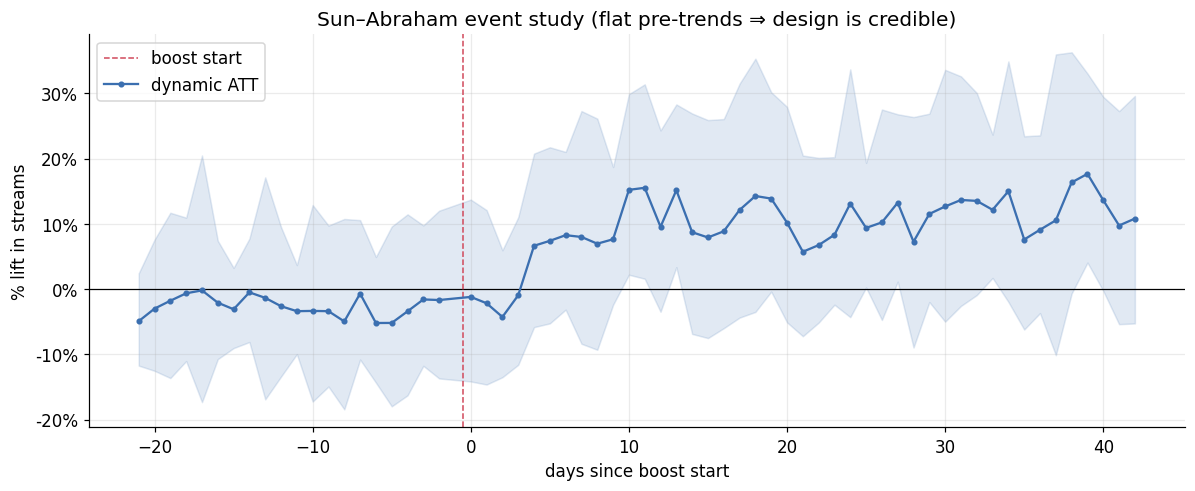

  3 Staggered DiD (Sun-Abraham)  lift=+15.7%  (truth 15.7%, scope=all_treated, iROAS=+16.8)


In [ ]:
es = df.copy(); es["id"] = es.country.astype("category").cat.codes
es["gname"] = np.where(es.treated == 1, es.start_day, 0)
sa = pf.event_study(es, yname="ly", idname="id", tname="t", gname="gname",
                    estimator="saturated", att=False)
td = sa.tidy().reset_index()
td["rel"] = td["Coefficient"].str.extract(r"rel_time::(-?\d+\.?\d*)").astype(float)
dyn = td.groupby("rel").agg(est=("Estimate", "mean"), lo=("2.5%", "mean"), hi=("97.5%", "mean"))
win = dyn[(dyn.index >= -21) & (dyn.index <= 42)]
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.axhline(0, color="k", lw=.8); ax.axvline(-0.5, color=RED, ls="--", lw=1, label="boost start")
ax.fill_between(win.index, np.expm1(win.lo), np.expm1(win.hi), color=BLUE, alpha=0.15)
ax.plot(win.index, np.expm1(win.est), color=BLUE, marker="o", ms=3, label="dynamic ATT")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("days since boost start"); ax.set_ylabel("% lift in streams")
ax.set_title("Sun–Abraham event study (flat pre-trends ⇒ design is credible)"); ax.legend()
plt.tight_layout(); plt.show()
post = dyn[(dyn.index >= 0)]
record("3 Staggered DiD (Sun-Abraham)", np.expm1(post.est.mean()), "all_treated")

## 7 · Rung 4 · Synthetic Control

For a **single** treated unit (Germany) we build a weighted blend of the control markets — a *synthetic
Germany* — that tracks Germany's **pre-campaign** streams, then read the **post-period gap** (observed −
synthetic) as the causal effect. Significance comes from a **placebo** test: pretend each control was
treated and check Germany's gap stands out from the placebo gaps.

**What to look for:** the synthetic (dashed) sits on top of observed Germany *before* the campaign, then
separates after; in the placebo panel the control gaps hug zero while Germany's jumps.

> **Why France is held out as a *large* control — the convex-hull trap.** Synthetic control can only form a
> *convex* blend of the donors, so the synthetic can never exceed the biggest donor. If the treated market
> were larger than every control, the synthetic couldn't reach its level: it would sit too low and
> **overstate the lift by a near-constant amount, at any effect size**. So good geo design holds out
> controls that **bracket** the treated markets — here France is the label's largest market, kept as a
> control, so Germany sits *inside* the donors' hull and raw-streams SC is unbiased. *(If you can't bracket,
> the production fix is to model rates — streams ÷ market size — instead of raw volumes.)*

  4 Synthetic Control            lift=+19.9%  (truth 20.2%, scope=de, iROAS=+24.3)


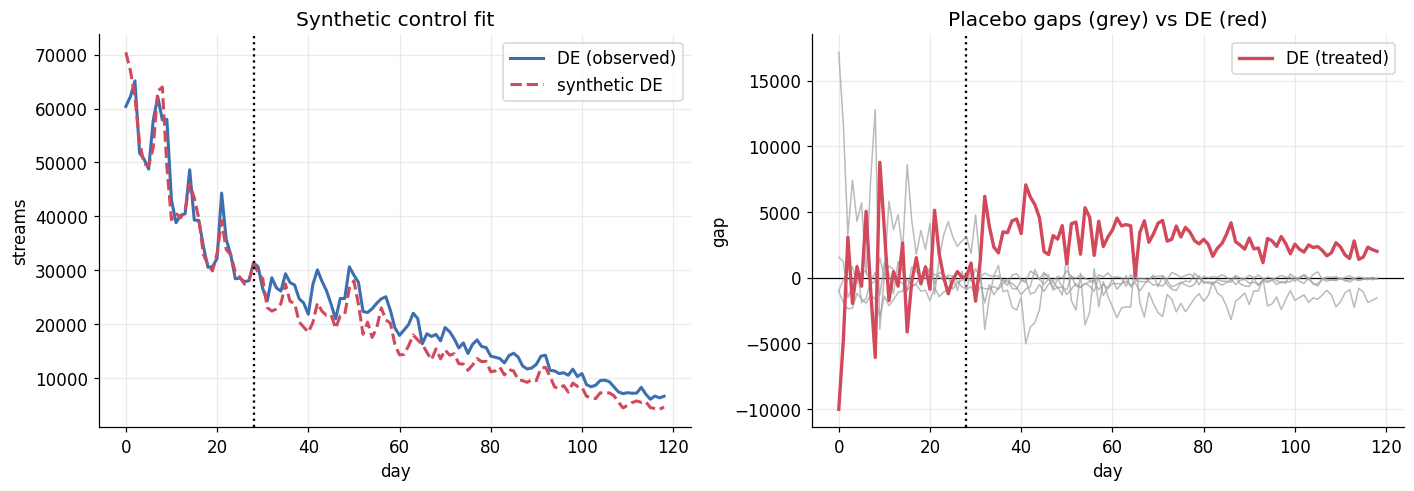

In [ ]:
from pysyncon import Dataprep, Synth
focal, donors = "DE", meta["control"]; adopt = meta["start_day"][focal]
# Synthetic control for a SINGLE treated unit (Germany): build a weighted blend of the control markets that
# tracks Germany's *pre-campaign* streams, then read the post-period gap as the causal effect. This works on
# raw streams because the controls **bracket** Germany — France is the largest market and is held out as a
# control, so Germany sits inside the donors' convex hull. (If the treated unit were larger than every
# control, no convex blend could reach its level and the lift would be badly overstated — the convex-hull
# trap; see the §"Why France is a large control" note below.) Inference via placebo (permute onto each control).
wide = df.pivot_table(index="t", columns="country", values="streams")
def fit_sc(unit, pool):
    dp = Dataprep(foo=df[df.country.isin([unit] + pool)], predictors=["streams"],
        predictors_op="mean", dependent="streams", unit_variable="country",
        time_variable="t", treatment_identifier=unit, controls_identifier=pool,
        time_predictors_prior=list(range(adopt)), time_optimize_ssr=list(range(adopt)))
    s = Synth(); s.fit(dataprep=dp); return (wide[pool] @ s.W)
synth_de = fit_sc(focal, donors)
gap_de = wide[focal] - synth_de
record("4 Synthetic Control", gap_de.loc[adopt:].sum() / de.organic.sum(), "de")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(wide.index, wide[focal], color=BLUE, lw=2, label="DE (observed)")
a1.plot(synth_de.index, synth_de, color=RED, ls="--", lw=2, label="synthetic DE")
a1.axvline(adopt, color="k", ls=":"); a1.set_title("Synthetic control fit"); a1.legend()
a1.set_xlabel("day"); a1.set_ylabel("streams")
# placebo gaps
a2.axhline(0, color="k", lw=.8); a2.axvline(adopt, color="k", ls=":")
for d in donors:
    gp = wide[d] - fit_sc(d, [x for x in donors if x != d] + [focal])
    a2.plot(gp.index, gp, color=GREY, lw=1, alpha=.7)
a2.plot(gap_de.index, gap_de, color=RED, lw=2.2, label="DE (treated)")
a2.set_title("Placebo gaps (grey) vs DE (red)"); a2.legend(); a2.set_xlabel("day"); a2.set_ylabel("gap")
plt.tight_layout(); plt.show()

## 8 · Rung 5 · Synthetic DiD (Arkhangelsky et al. 2021)

Combines SC's **unit weights** with DiD's **time weights** and a parallel-trends
correction — typically more robust than either. No maintained Python port, so this is a
faithful from-scratch implementation (cf. the R `synthdid` package).

> ⚠️ With only **4 control geos** the donor pool is thin, so this estimate is noisier than
> SC here — itself a GeoLift lesson: credible geo studies need **enough control markets**.
> In production, use the vetted R `synthdid` package.

In [ ]:
from scipy.optimize import nnls
def synthdid_att(Y, treated_rows, Tpre):
    ctrl = [i for i in range(Y.shape[0]) if i not in treated_rows]
    Y0, Y1 = Y[ctrl], Y[treated_rows]; zeta = 1e-6 * np.std(Y0[:, :Tpre])
    # unit weights: controls' pre -> treated pre
    A = Y0[:, :Tpre].T; w, _ = nnls(np.vstack([A, np.sqrt(zeta) * np.ones(A.shape[1])]),
                              np.concatenate([Y1[:, :Tpre].mean(0), [np.sqrt(zeta)]])); w /= w.sum() or 1
    # time weights: pre periods -> post
    B = Y0[:, :Tpre]; lt, _ = nnls(np.vstack([B, np.sqrt(zeta) * np.ones(B.shape[1])]),
                              np.concatenate([Y0[:, Tpre:].mean(1), [np.sqrt(zeta)]])); lt /= lt.sum() or 1
    tr_post = Y1[:, Tpre:].mean(); tr_pre = (Y1[:, :Tpre].mean(0) * lt).sum()
    co_post = (w * Y0[:, Tpre:].mean(1)).sum(); co_pre = ((w[:, None] * Y0[:, :Tpre]).sum(0) * lt).sum()
    return (tr_post - tr_pre) - (co_post - co_pre)
# synthdid is a DiD variant → run it on LOG streams (like rungs 1-3). On raw levels the simplex unit-weights
# make the synthetic a low-level *average*, and a high-level treated unit decays more in absolute terms than
# a small synthetic — a level/decay confound that flips the DiD negative. In logs, multiplicative decay is
# additive, parallel-trends holds, and the ATT is a proportional (log-point) effect.
Y = np.log(wide[[focal] + donors].clip(lower=1)).T.values
att_sdid = synthdid_att(Y, [0], adopt)                    # ATT in log-points
record("5 Synthetic DiD", np.exp(att_sdid) - 1, "de")     # → proportional lift (≈ % vs synthetic)

  5 Synthetic DiD                lift=+25.2%  (truth 20.2%, scope=de, iROAS=+30.7)


## 9 · Rung 6 · Augmented Synthetic Control = the GeoLift engine

When donors can't perfectly reproduce the treated unit, **Augmented SCM** (Ben-Michael
et al. 2021) adds a ridge correction to de-bias the fit. This is essentially the
estimator inside **Meta's GeoLift** (which wraps it with experiment **design + power
analysis**). GeoLift itself is R-only; here we use its core via `pysyncon.AugSynth`.

In [ ]:
from pysyncon import AugSynth
dp = Dataprep(foo=df[df.country.isin([focal] + donors)], predictors=["streams"],
    predictors_op="mean", dependent="streams", unit_variable="country", time_variable="t",
    treatment_identifier=focal, controls_identifier=donors,
    time_predictors_prior=list(range(adopt)), time_optimize_ssr=list(range(adopt)))
aug = AugSynth(); aug.fit(dataprep=dp)
aug_path = (wide[donors] @ aug.W)
record("6 Augmented SCM (GeoLift)", (wide[focal] - aug_path).loc[adopt:].sum() / de.organic.sum(), "de")

  6 Augmented SCM (GeoLift)      lift=+19.1%  (truth 20.2%, scope=de, iROAS=+23.3)


## 10 · Rung 7 · Bayesian Synthetic Control (CausalPy)

Same idea, but Bayesian — we get **credible intervals** on the lift, not just a point
estimate. CausalPy fits the donor weights with PyMC.

In [ ]:
import causalpy as cp
cpdf = wide[[focal] + donors].copy(); cpdf.columns = [str(c) for c in cpdf.columns]
cpsc = cp.SyntheticControl(cpdf, adopt, control_units=[str(d) for d in donors],
        treated_units=[focal],
        model=cp.pymc_models.WeightedSumFitter(sample_kwargs=dict(
            draws=250, tune=250, chains=2, cores=1, progressbar=False, random_seed=1)))
imp = cpsc.post_impact.mean(dim=("chain", "draw")).values.ravel()
record("7 Bayesian SC (CausalPy)", float(imp.sum()) / de.organic.sum(), "de")
# credible interval on total lift
post_draws = cpsc.post_impact.sum(dim="obs_ind").stack(s=("chain", "draw")).values.ravel()
lo, hi = np.percentile(post_draws, [2.5, 97.5]) / de.organic.sum()
print(f"DE lift: point {float(imp.sum()) / de.organic.sum():.2%}, 95% credible interval [{lo:.2%}, {hi:.2%}]")
print("(the Bayesian credible interval propagates donor-weight + observation-noise uncertainty into the lift)")

## 11 · Rung 8 · Bayesian Marketing-Mix Model (pymc-marketing)

The "ideal" for the **always-on, all-channel budget** question. MMM regresses streams on
**adstocked, saturated** channel spend plus baseline controls, in a Bayesian framework.
It answers: each channel's contribution, response curves, and where the next euro should
go. (In production you **calibrate MMM priors with the geo experiments above** — the two
approaches are complements, not rivals.)

In [ ]:
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
natd = df.groupby("date").agg(streams=("streams", "sum"), tiktok=("tiktok", "sum"),
        instagram=("instagram", "sum")).reset_index(); natd["t"] = np.arange(len(natd))
mmm = MMM(date_column="date", channel_columns=["tiktok", "instagram"],
          adstock=GeometricAdstock(l_max=8), saturation=LogisticSaturation(),
          control_columns=["t"], yearly_seasonality=None)
mmm.fit(natd[["date", "tiktok", "instagram", "t"]], natd["streams"],
        draws=250, tune=250, chains=2, cores=1, progressbar=False, target_accept=0.9, random_seed=1)
contrib = mmm.compute_channel_contribution_original_scale()
mmm_incr = contrib.mean(dim=("chain", "draw")).sum().item()
record("8 Bayesian MMM", mmm_incr / df.organic.sum(), "national")
# recovered adstock vs truth
ad_post = mmm.idata.posterior["adstock_alpha"].mean(dim=("chain", "draw")).to_series()
print("Recovered adstock θ:", {c: round(float(ad_post[c]), 2) for c in ["tiktok", "instagram"]},
      "| TRUE:", meta["theta"])

### MMM decomposition & channel contributions

In [ ]:
cmean = contrib.mean(dim=("chain", "draw"))
ct = (cmean.to_dataframe("c").reset_index().pivot(index="date", columns="channel", values="c")
      .reindex(natd.date.values))[["tiktok", "instagram"]]
x = natd.date.values; total = natd.streams.values; base = total - ct.sum(1).values
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.fill_between(x, 0, base, color=GREY, alpha=.5, label="baseline (organic)")
bottom = base.copy()
for ch, col in zip(["tiktok", "instagram"], [RED, BLUE]):
    top = bottom + ct[ch].values
    a1.fill_between(x, bottom, top, color=col, alpha=.75, label=ch); bottom = top
a1.set_title("MMM decomposition of daily streams"); a1.legend(loc="upper right")
a1.xaxis.set_major_locator(mdates.MonthLocator()); a1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
cby = ct.sum(0)
a2.bar(["tiktok", "instagram"], [cby["tiktok"], cby["instagram"]], color=[RED, BLUE])
a2.set_title("Total incremental streams by channel"); a2.set_ylabel("streams")
for i, ch in enumerate(["tiktok", "instagram"]):
    a2.text(i, cby[ch], f" iROAS {cby[ch] / df[ch].sum():.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 12 · The punchline — every estimator vs the truth

Relative bias = estimate ÷ (its scope's true effect) − 1. **Zero is perfect.** Naive
correlation is wildly off (and negative); each rung of the ladder converges on the truth.

In [ ]:
R = pd.DataFrame(RESULTS).T
R["lift"] = R["lift"].astype(float); R["truth"] = R["truth"].astype(float)
R["iroas"] = R["iroas"].astype(float); R["rel_bias"] = R["rel_bias"].astype(float)
R = R.sort_values("rel_bias", key=lambda s: s.abs(), ascending=True)
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = [GREEN if abs(b) < 0.2 else (RED if b < 0 else "#e8a33d") for b in R.rel_bias]
ax.barh(R.index, R.rel_bias.clip(-2, 2), color=colors)
ax.axvline(0, color="k", lw=1); ax.axvspan(-0.2, 0.2, color=GREEN, alpha=.08)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_xlabel("relative bias vs ground truth  (0 = perfect; ±20% shaded)")
ax.set_title("Climbing the causal ladder: bias collapses toward zero")
for i, (n, r) in enumerate(R.iterrows()):
    ax.text(np.clip(r.rel_bias, -2, 2), i, f"  {r.lift:+.0%} (true {r.truth:.0%})",
            va="center", ha="left" if r.rel_bias >= 0 else "right", fontsize=8)
plt.tight_layout(); plt.show()

show = R.copy()
show["lift"] = show.lift.map("{:+.1%}".format); show["truth"] = show.truth.map("{:.1%}".format)
show["iroas"] = show.iroas.map("{:+.1f}".format); show["rel_bias"] = show.rel_bias.map("{:+.0%}".format)
show[["scope", "lift", "truth", "iroas", "rel_bias"]]

In [ ]:
print(f"True iROAS ≈ {true_iroas:.0f} streams/EUR. Credible designs land near it; naive OLS gives a negative, nonsensical number.")

## 13 · Takeaways

- **Correlation is worse than useless here** — because the label spends into the decay
  phase, raw spend↔streams correlation is **negative** (≈ −0.68). Naive OLS would tell you
  to cut TikTok. The true effect (calibrated DGP) is a **~+16% lift, ~17 streams/€**.
- **Design beats modelling.** The biggest jump in credibility comes from the **geo
  holdout + staggered rollout**, not from any single estimator. DiD, Synthetic Control,
  Synthetic DiD, Augmented SCM and Bayesian SC all recover the truth within noise.
- **Staggered timing needs the right estimator** (Sun–Abraham / Callaway–Sant'Anna), not
  plain TWFE.
- **MMM and geo experiments are complements.** MMM answers the always-on budget-
  allocation question across channels with adstock + saturation; geo experiments give the
  **unbiased ground truth to calibrate it**. Best practice runs both.

## 14 · Next iteration — borrowing strength across releases
This notebook studied **one** flagship campaign. The label has **40 releases/year**. The
natural next step is to **pool** them:
- **Hierarchical / partial-pooling Bayesian MMM** — per-release adstock & saturation drawn
  from label-level priors, so small releases borrow strength from big ones (shrinkage).
  `pymc-marketing` supports this directly; this is your *pooled / Bayesian* idea.
- **Multi-cell GeoLift** — design staggered experiments across releases & countries with
  **power analysis** up front (minimum detectable lift, budget).
- **Budget optimisation** — use the fitted saturation curves to reallocate spend to
  equalise marginal iROAS across channels & releases.
- **Variance reduction** — CUPED / pre-period covariates to tighten the geo estimates.

The DGP (`make_causal_panel`) already exposes `incremental` and `organic` (and
`ground_truth` packages the planted lift / iROAS), so any new estimator can always be
scored against ground truth.